### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [6]:
data = pd.read_csv('data/coupons.csv')

In [7]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [8]:
#Check the data summary
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [9]:
#checking missing values
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [10]:
#Identify the info in the column car
data["car"].value_counts()

car
Scooter and motorcycle                      22
Mazda5                                      22
do not drive                                22
crossover                                   21
Car that is too old to install Onstar :D    21
Name: count, dtype: int64

In [11]:
#drop the column car
d_c= data.drop(columns=["car"])
d_c

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


4. What proportion of the total observations chose to accept the coupon?



In [12]:
(d_c["Y"] == 1).sum()/ d_c['Y'].count()

0.5684326710816777

5. Use a bar plot to visualize the `coupon` column.

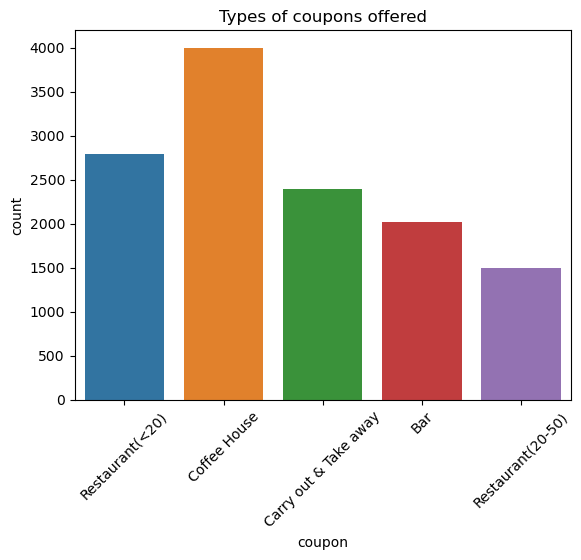

In [13]:
sns.countplot(x="coupon", data=d_c)
plt.title("Types of coupons offered")
plt.xticks(rotation=45)
plt.show()

6. Use a histogram to visualize the temperature column.

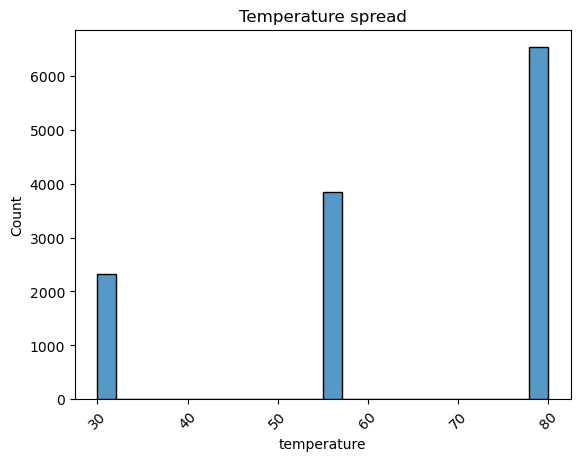

In [14]:
sns.histplot(d_c["temperature"])
plt.title("Temperature spread")
plt.xticks(rotation=45)
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [15]:
d_c_bar = d_c[d_c['coupon'] == 'Bar']
d_c_bar

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


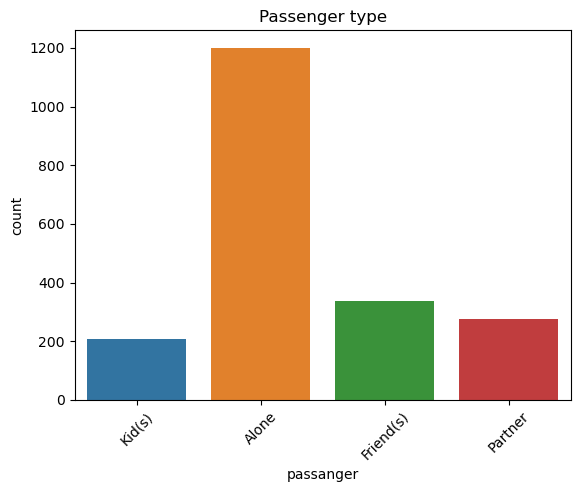

In [16]:
sns.countplot(x="passanger", data=d_c_bar)
plt.title("Passenger type")
plt.xticks(rotation=45)
plt.show()

2. What proportion of bar coupons were accepted?


In [17]:
(d_c_bar["Y"] == 1).sum()/ d_c_bar['Y'].count()

0.41001487357461575

<Axes: xlabel='Bar', ylabel='count'>

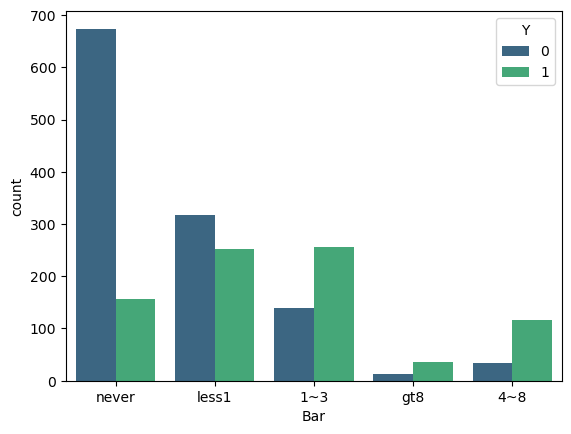

In [18]:
sns.countplot(data=d_c_bar, x='Bar', hue='Y', palette='viridis')

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [19]:
#visualize the counts for various visits in the bar
d_c_bar['Bar'].value_counts()

Bar
never    830
less1    570
1~3      397
4~8      150
gt8       49
Name: count, dtype: int64

In [20]:
#acceptance rate of those who went to a bar 3 or fewer times a month 
Bar_less_3 = d_c_bar["Bar"].isin(["never", "less1", "1~3"]).sum()
acceptance_rate_less_3 = (d_c_bar["Bar"].isin(["never", "less1", "1~3"]) & (d_c_bar["Y"] == 1)).sum() / Bar_less_3
acceptance_rate_less_3

0.37061769616026713

In [21]:
#acceptance rate of those who went to a bar 4 or more times a month 
Bar_more_4 = d_c_bar["Bar"].isin(["4~8", "gt8"]).sum()
acceptance_rate_more_4 = (d_c_bar["Bar"].isin(["4~8", "gt8"]) & (d_c_bar["Y"] == 1)).sum() / Bar_more_4
acceptance_rate_more_4

0.7688442211055276

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [22]:
#visualize the counts for drivers age who go to the bar
d_c_bar['age'].value_counts()

age
21         417
26         395
31         339
50plus     283
36         209
41         178
46         109
below21     87
Name: count, dtype: int64

In [23]:
# acceptance rate of drivers who go to a bar more than once a month and are over the age of 25
combined = (d_c_bar["Bar"].isin(["1~3", "4~8", "gt8"])) & (d_c_bar["age"].isin(["26", "31", "50plus", "36", "41", "46"]))
acceptance_rate_more_1_more_25 = d_c_bar.loc[combined & (d_c_bar["Y"] == 1)].shape[0] / d_c_bar.loc[combined].shape[0]

acceptance_rate_more_1_more_25

0.6952380952380952

In [24]:
acceptance_others = d_c_bar.loc[d_c_bar.index.difference(combined, sort = False)]

(acceptance_others[acceptance_others["Y"] == 1].shape[0] / acceptance_others.shape[0]) * 100

41.00148735746158

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [25]:
#visualize the counts for drivers with passenger type
d_c_bar['passanger'].value_counts()

passanger
Alone        1200
Friend(s)     337
Partner       274
Kid(s)        206
Name: count, dtype: int64

In [26]:
#visualize the counts for drivers' occupation
d_c_bar['occupation'].value_counts()

occupation
Unemployed                                   301
Student                                      251
Computer & Mathematical                      232
Sales & Related                              178
Education&Training&Library                   140
Management                                   119
Office & Administrative Support              105
Arts Design Entertainment Sports & Media     100
Business & Financial                          89
Retired                                       75
Food Preparation & Serving Related            48
Community & Social Services                   44
Healthcare Support                            44
Healthcare Practitioners & Technical          41
Transportation & Material Moving              35
Legal                                         34
Architecture & Engineering                    27
Personal Care & Service                       27
Protective Service                            27
Construction & Extraction                     24
Life Phys

In [27]:
# acceptance rate of drivers who go to a bar more than once a month and and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.
combined_3 = d_c_bar["Bar"].isin(["1~3", "4~8", "gt8"]) &  d_c_bar["passanger"].isin(["Friend(s)", "Partner"]) & (d_c_bar["occupation"] != "Farming Fishing & Forestry")

acceptance_rate_more_1_pass_not_kid_Farming = (d_c_bar.loc[combined_3 & (d_c_bar["Y"] == 1)].shape[0] / d_c_bar.loc[combined_3].shape[0])

acceptance_rate_more_1_pass_not_kid_Farming



0.717948717948718

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [28]:
#visualize the counts for drivers marital status
d_c_bar['maritalStatus'].value_counts()

maritalStatus
Married partner      882
Single               661
Unmarried partner    378
Divorced              75
Widowed               21
Name: count, dtype: int64

In [29]:
#visualize the counts for drivers income
d_c_bar['income'].value_counts()

income
$25000 - $37499     318
$100000 or More     291
$12500 - $24999     288
$37500 - $49999     267
$50000 - $62499     262
Less than $12500    165
$75000 - $87499     151
$87500 - $99999     145
$62500 - $74999     130
Name: count, dtype: int64

In [30]:
#visualize the counts for cheap restaurants
d_c_bar['RestaurantLessThan20'].value_counts()

RestaurantLessThan20
1~3      878
4~8      568
less1    325
gt8      186
never     37
Name: count, dtype: int64

In [31]:
combined_all = ((d_c_bar["Bar"].isin(["1~3", "4~8", "gt8"]) & d_c_bar["passanger"].isin(["Friend(s)", "Partner"]) & (d_c_bar["maritalStatus"] != "Widowed")) |
    (d_c_bar["Bar"].isin(["1~3", "4~8", "gt8"]) & d_c_bar["age"].isin(["21", "26", "below21"])) |
    (d_c_bar["RestaurantLessThan20"].isin(["4~8", "gt8"]) & d_c_bar["income"].isin(["$25000 - $37499", "$12500 - $24999", "$37500 - $49999", "Less than $12500"])))
acceptance_rate_combined_all = (d_c_bar.loc[combined_all & (d_c_bar["Y"] == 1)].shape[0] / d_c_bar.loc[combined_all].shape[0])
acceptance_rate_combined_all

0.5692771084337349

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [32]:
# Majority of drivers who went to the bar went alone. Drivers with kids visited the bar the least.
# Around 41% of the bar coupons were accepted compared to the 56% of the total coupons accepted.
# 76% of the drivers accepted the coupons who go to the bar more than 4 times a month compared to acceptance rate of 37% for those who went to a bar 3 or fewer times a month 
# Acceptance rate of drivers who go to a bar more than once a month and are over the age of 25 is around 70%, which is very similar to the acceptance rate of drivers who go to a bar more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry, which is around 71%

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [33]:
d_c_h = d_c[d_c['coupon'] == 'Coffee House']
d_c_h

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,0
12659,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,never,4~8,gt8,less1,1,0,0,1,0,0
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


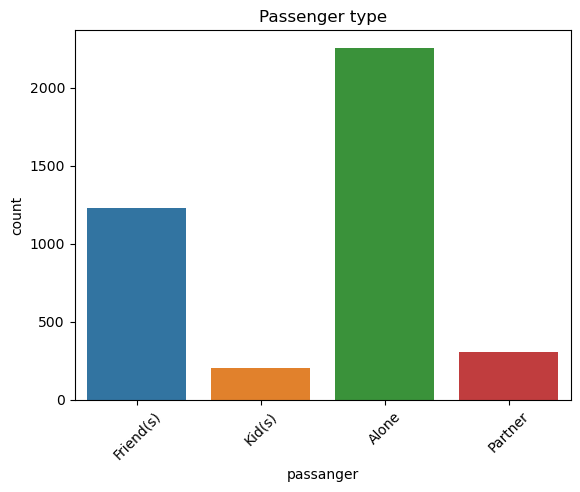

In [34]:
sns.countplot(x="passanger", data=d_c_h)
plt.title("Passenger type")
plt.xticks(rotation=45)
plt.show()

In [35]:
(d_c_h["Y"] == 1).sum()/ d_c_h['Y'].count()

0.49924924924924924

In [36]:
#visualize the counts for various visits in the Coffee House
d_c_h['CoffeeHouse'].value_counts()

CoffeeHouse
less1    1075
1~3      1042
never     927
4~8       538
gt8       342
Name: count, dtype: int64

In [37]:
d_c_h['gender'].value_counts()

gender
Female    2051
Male      1945
Name: count, dtype: int64

In [38]:
d_c_h['Y'].value_counts()

Y
0    2001
1    1995
Name: count, dtype: int64

In [39]:
#acceptance rate of those who went to a coffee house 3 or fewer times a month 
CH_less_3 = d_c_h["CoffeeHouse"].isin(["never", "less1", "1~3"]).sum()
CH_acceptance_rate_less_3 = (d_c_h["CoffeeHouse"].isin(["never", "less1", "1~3"]) & (d_c_h["Y"] == 1)).sum() / CH_less_3
CH_acceptance_rate_less_3

0.44940867279894875

In [40]:
#acceptance rate of those who went to a coffee house 4 or more times a month 
CH_more_4 = d_c_bar["CoffeeHouse"].isin(["4~8", "gt8"]).sum()
CH_acceptance_rate_more_4 = (d_c_bar["CoffeeHouse"].isin(["4~8", "gt8"]) & (d_c_bar["Y"] == 1)).sum() / CH_more_4
CH_acceptance_rate_more_4

0.45806451612903226

In [55]:
# % for females who accepted CoffeeHouse coupons
combined_females_accepted = (d_c_h["gender"] == "Female") & (d_c_h["Y"] == 1)
acceptance_rate_CH_Female = d_c_h.loc[combined_females_accepted].shape[0] / (d_c_h["gender"] == "Female").sum()
acceptance_rate_CH_Female

0.492442710872745

In [59]:
# % for males who accepted CoffeeHouse coupons
combined_males_accepted = (d_c_h["gender"] == "Male") & (d_c_h["Y"] == 1)
acceptance_rate_CH_Male = d_c_h.loc[combined_males_accepted].shape[0] / (d_c_h["gender"] == "Male").sum()
acceptance_rate_CH_Male

0.506426735218509

In [43]:
# Majority of drivers who went to the bar went alone. Drivers with kids visited the bar the least.
# Drivers who went to a coffee house 3 or fewer times a month and who went to a coffee house 4 or more times a month accepted the coupons around 50%
# The acceptance rate of coupons for both genders is around 50%